# Burgers equation

### Configuration

In [1]:
from __init__ import create_config, figures
from IPython.display import display

config = create_config(
    system="burgers",
    n_states=32,
    seed=42,
    n_controls=2,
    t1_initial=15.0,
    t1_max=60.0,
)
cache_dir = f"./cache_seed{config.seed}"
figures.save_config_table(config)
figures.show_spec(config, keys=["system", "seed", "n_states", "n_controls", "t1_initial", "nu"], title="Burgers configuration")

**Burgers configuration**

system,seed,n_states,n_controls,t1_initial,nu
burgers,42,32,2,15.000000,0.012000


### Data Generation

In [2]:
controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (pre)": {"enabled": True},
    "GradQRNet (ad)": {"enabled": True},
}


Solving open loop OCPs...

 attempted |  solved   |  desired  
-----------------------------------


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


$N_{\mathrm{traj}}$,$|\mathcal{D}|$,t (max),|x| (mean),|x| (max),$\|x\|$ (mean),$\|x\|$ (max)
10,1239,4.570762,0.214870,1.285600,0.423494,1.068467


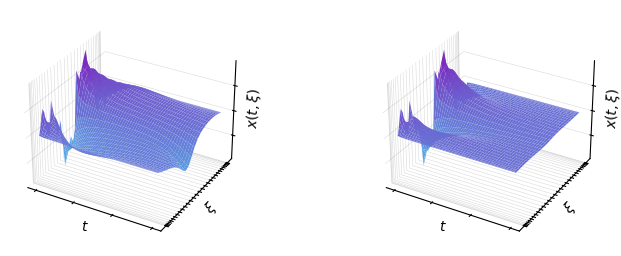

In [3]:
import matplotlib.pyplot as plt
from data import load_or_generate

n_trajectories = 10
n_candidates = 200
n_MC = 10

data_train, data_val, meta = load_or_generate(config, n_trajectories=n_trajectories, n_candidates=n_candidates, controller=config.ocp.LQR)
data = data_train  # Keep using 'data' for backward compatibility

summary_df = figures.save_data_summary_table(config, data)

display(summary_df.style.hide(axis="index"))

fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### Model Training

In [4]:
from controls.train import TrainConfig

cfg = TrainConfig(batch_size=int(config.n_states), horizon=25, unsup_n_steps=100, unsup_epochs=4, n_candidates=n_candidates)

# 1. Save to LaTeX using the new generic function
figures.save_params_table(cfg, "traincfg.tex", title="Training Configuration", config=config)

figures.show_spec(
    cfg,
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "n_candidates", "dt_min", "dt_max", "grad_clip"],
    title="Training configuration"
)

**Training configuration**

sup_epochs,sup_lr,unsup_epochs,unsup_n_steps,unsup_lr,horizon,batch_size,n_candidates,dt_min,dt_max,grad_clip
1,0.000010,4,100,0.000500,25,32,200,0.000000,0.100000,None



Training: GradQRNet
epoch 0001 | loss=6.77e-02 | hjb=9.88e-02 | sup=0.00e+00 | bs=32 | val_mse=3.68e+00
epoch 0002 | loss=1.74e-02 | hjb=2.29e-02 | sup=0.00e+00 | bs=32 | val_mse=3.67e+00
epoch 0003 | loss=1.75e-02 | hjb=2.08e-02 | sup=0.00e+00 | bs=32 | val_mse=3.67e+00
epoch 0004 | loss=1.72e-02 | hjb=1.83e-02 | sup=0.00e+00 | bs=32 | val_mse=3.67e+00

Training: GradQRNet (sup)
epoch 0001 | loss=4.91e-01 | hjb=9.40e-02 | sup=1.40e-01 | bs=32 | val_mse=3.45e+00
epoch 0002 | loss=3.38e-01 | hjb=2.57e-02 | sup=1.34e-01 | bs=32 | val_mse=3.19e+00
epoch 0003 | loss=2.10e-01 | hjb=2.24e-02 | sup=1.20e-01 | bs=32 | val_mse=3.08e+00
epoch 0004 | loss=9.09e-02 | hjb=1.83e-02 | sup=1.22e-01 | bs=32 | val_mse=3.06e+00

Training: GradQRNet (pre)
epoch 0001 | loss=1.47e+00 | hjb=4.47e-01 | sup=1.47e-01 | bs=32 | val_mse=3.72e+00
epoch 0001 | loss=5.25e-02 | hjb=7.67e-02 | sup=0.00e+00 | bs=32 | val_mse=3.67e+00
epoch 0002 | loss=1.88e-02 | hjb=2.48e-02 | sup=0.00e+00 | bs=32 | val_mse=3.66e+00
e

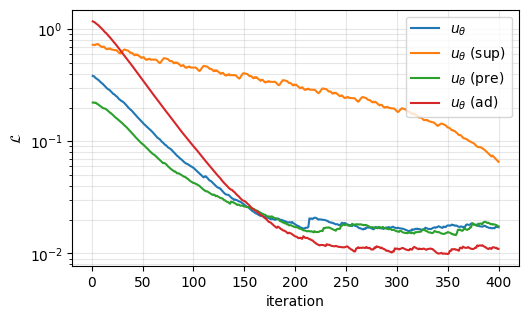

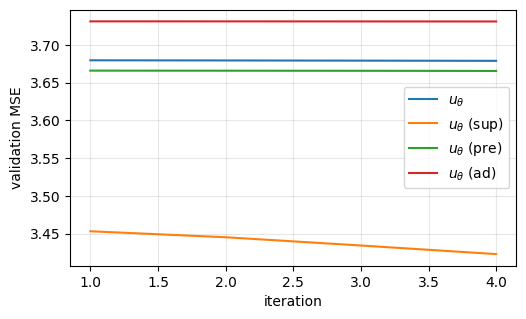

In [5]:
from controls.model_factory import train_controllers

trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
)
plt.show()

figures.plot_training_val_mse(
    config=config,
    histories=histories,
    controller_configs=controller_configs,
)
plt.show()

### Evaluation: Stability and Optimality

In [6]:
controllers = [
    ("LQR (Baseline)", config.ocp.LQR),
] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]

In [7]:
from simulation import monte_carlo

results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 10/10 [00:04<00:00,  2.19it/s]


Controller,Stability (S),Cost J (mean),t_conv (mean)
LQR (Baseline),70.0%,0.4052,10.41
GradQRNet,70.0%,0.3975,10.88
GradQRNet (sup),70.0%,0.4088,11.72
GradQRNet (pre),70.0%,0.3965,11.15
GradQRNet (ad),80.0%,0.5419,11.36


,Model,Stability $S$,Cost $J$ (mean),$t_{\text{conv}}$ (mean)
0,LQR (Baseline),0.7,0.405197,10.411778
1,GradQRNet,0.7,0.397466,10.883666
2,GradQRNet (sup),0.7,0.408803,11.724111
3,GradQRNet (pre),0.7,0.396514,11.151313
4,GradQRNet (ad),0.8,0.541942,11.364120


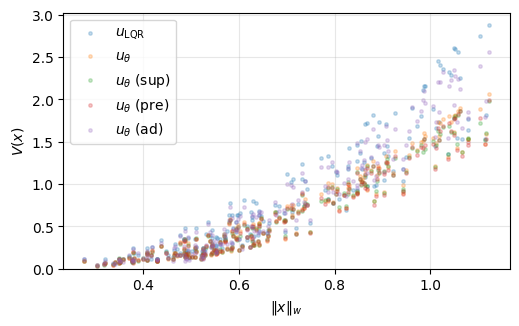

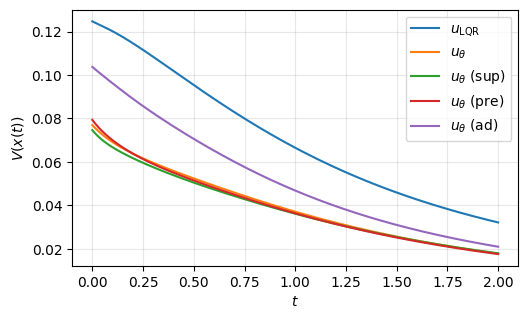

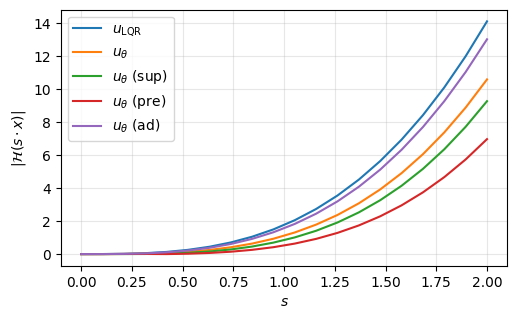

In [8]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
)
plt.show()

### Combined Architectures

In [9]:
controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (pre/ad)": {"enabled": True},
    "GradQRNet (pre/sup/ad)": {"enabled": True},
}


Training: GradQRNet

Training: GradQRNet (pre/sup)
epoch 0001 | loss=1.47e+00 | hjb=4.50e-01 | sup=1.47e-01 | bs=32 | val_mse=3.73e+00
epoch 0001 | loss=4.81e-01 | hjb=9.90e-02 | sup=1.36e-01 | bs=32 | val_mse=3.49e+00
epoch 0002 | loss=3.46e-01 | hjb=2.19e-02 | sup=1.38e-01 | bs=32 | val_mse=3.29e+00
epoch 0003 | loss=2.10e-01 | hjb=1.95e-02 | sup=1.23e-01 | bs=32 | val_mse=3.20e+00
epoch 0004 | loss=9.06e-02 | hjb=1.69e-02 | sup=1.27e-01 | bs=32 | val_mse=3.17e+00

Training: GradQRNet (sup/ad)
epoch 0001 | loss=5.66e-01 | hjb=1.82e-01 | sup=1.46e-01 | bs=32 | val_mse=3.63e+00
epoch 0002 | loss=3.67e-01 | hjb=4.05e-02 | sup=1.41e-01 | bs=32 | val_mse=3.57e+00
epoch 0003 | loss=2.65e-01 | hjb=5.36e-02 | sup=1.39e-01 | bs=32 | val_mse=3.55e+00
epoch 0004 | loss=1.20e-01 | hjb=3.99e-02 | sup=1.43e-01 | bs=32 | val_mse=3.54e+00

Training: GradQRNet (pre/ad)
epoch 0001 | loss=1.47e+00 | hjb=4.42e-01 | sup=1.47e-01 | bs=32 | val_mse=3.73e+00
epoch 0001 | loss=1.51e-01 | hjb=2.24e-01 | sup=

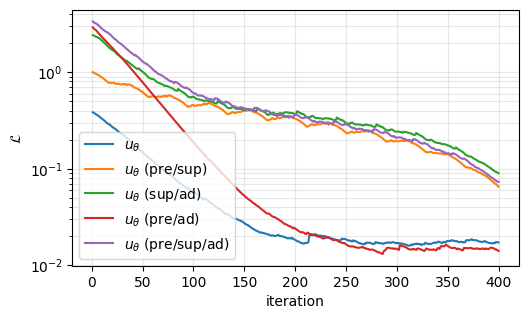

In [10]:
trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,  # Use the config defined above
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
    plot_name="combined_loss_curve",
);
plt.show()

figures.plot_training_val_mse(
    config=config,
    histories=histories,
    controller_configs=controller_configs,
);
plt.show()

In [11]:
controllers = [(name, trained_controllers[name]) for name in trained_controllers.keys()]

In [12]:
results = monte_carlo(config.ocp, config, controllers, n_MC=n_MC)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_combined.tex")

 10%|█         | 1/10 [00:00<00:06,  1.47it/s]

Trajectory 0 NOT converged - final_dists[0] = inf


 20%|██        | 2/10 [00:02<00:10,  1.32s/it]

Trajectory 1 NOT converged - final_dists[1] = inf


 40%|████      | 4/10 [00:04<00:06,  1.05s/it]

...

 40%|████      | 4/10 [00:06<00:08,  1.37s/it]

Trajectory 2 NOT converged - final_dists[2] = inf


100%|██████████| 10/10 [00:09<00:00,  1.00it/s]


Controller,Stability (S),Cost J (mean),t_conv (mean)
GradQRNet,40.0%,1.0746,18.95
GradQRNet (pre/sup),40.0%,0.6998,15.51
GradQRNet (sup/ad),80.0%,1.0077,17.21
GradQRNet (pre/ad),30.0%,0.5061,12.55
GradQRNet (pre/sup/ad),60.0%,0.7945,17.02


,Model,Stability $S$,Cost $J$ (mean),$t_{\text{conv}}$ (mean)
0,GradQRNet,0.4,1.074612,18.950386
1,GradQRNet (pre/sup),0.4,0.699775,15.505702
2,GradQRNet (sup/ad),0.8,1.007678,17.209919
3,GradQRNet (pre/ad),0.3,0.506086,12.546101
4,GradQRNet (pre/sup/ad),0.6,0.794465,17.021868


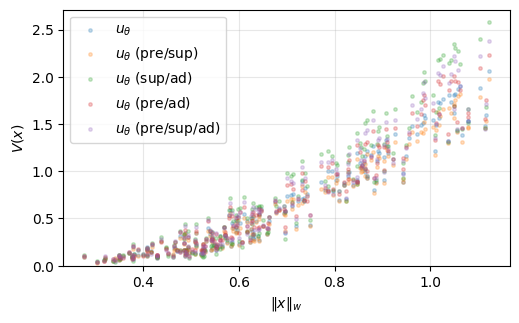

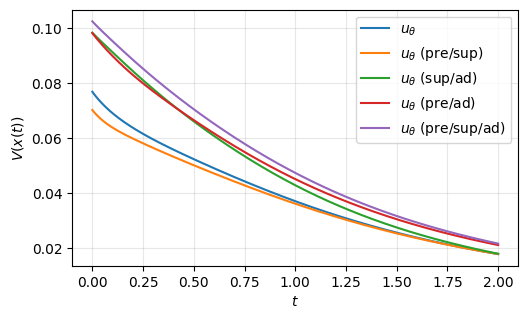

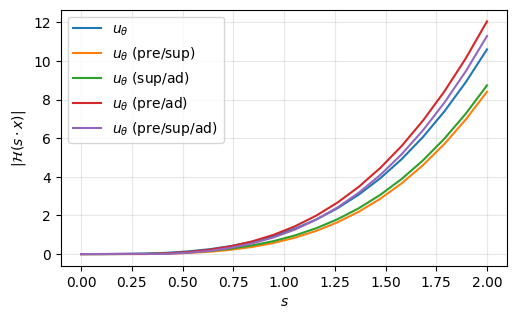

In [13]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
    suffix="_2",
)
plt.show()